## Project Description: Next Word Prediction Using LSTM
#### Project Overview:

This project aims to develop a deep learning model for predicting the next word in a given sequence of words. The model is built using Long Short-Term Memory (LSTM) networks, which are well-suited for sequence prediction tasks. The project includes the following steps:

1- Data Collection: We use the text of Shakespeare's "Hamlet" as our dataset. This rich, complex text provides a good challenge for our model.

2- Data Preprocessing: The text data is tokenized, converted into sequences, and padded to ensure uniform input lengths. The sequences are then split into training and testing sets.

3- Model Building: An LSTM model is constructed with an embedding layer, two LSTM layers, and a dense output layer with a softmax activation function to predict the probability of the next word.

4- Model Training: The model is trained using the prepared sequences, with early stopping implemented to prevent overfitting. Early stopping monitors the validation loss and stops training when the loss stops improving.

5- Model Evaluation: The model is evaluated using a set of example sentences to test its ability to predict the next word accurately.

6- Deployment: A Streamlit web application is developed to allow users to input a sequence of words and get the predicted next word in real-time.

In [1]:
## Data Collection
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
import  pandas as pd

## load the dataset
data=gutenberg.raw('shakespeare-hamlet.txt')
## save to a file
with open('hamlet.txt','w') as file:
    file.write(data)

[nltk_data] Downloading package gutenberg to C:\Users\S S
[nltk_data]     Shubaash\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\gutenberg.zip.


In [2]:
## Data Preprocessing

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

##laod the dataset
with open('hamlet.txt','r') as file:
    text=file.read().lower()

## Tokenize the text-creating indexes for words
tokenizer=Tokenizer()
tokenizer.fit_on_texts([text])
total_words=len(tokenizer.word_index)+1
total_words



4818

In [3]:
tokenizer.word_index

{'the': 1,
 'and': 2,
 'to': 3,
 'of': 4,
 'i': 5,
 'you': 6,
 'a': 7,
 'my': 8,
 'it': 9,
 'in': 10,
 'that': 11,
 'ham': 12,
 'is': 13,
 'not': 14,
 'his': 15,
 'this': 16,
 'with': 17,
 'your': 18,
 'but': 19,
 'for': 20,
 'me': 21,
 'lord': 22,
 'as': 23,
 'what': 24,
 'he': 25,
 'be': 26,
 'so': 27,
 'him': 28,
 'haue': 29,
 'king': 30,
 'will': 31,
 'no': 32,
 'our': 33,
 'we': 34,
 'on': 35,
 'are': 36,
 'if': 37,
 'all': 38,
 'then': 39,
 'shall': 40,
 'by': 41,
 'thou': 42,
 'come': 43,
 'or': 44,
 'hamlet': 45,
 'good': 46,
 'do': 47,
 'hor': 48,
 'her': 49,
 'let': 50,
 'now': 51,
 'thy': 52,
 'how': 53,
 'more': 54,
 'they': 55,
 'from': 56,
 'enter': 57,
 'at': 58,
 'was': 59,
 'oh': 60,
 'like': 61,
 'most': 62,
 'there': 63,
 'well': 64,
 'know': 65,
 'selfe': 66,
 'would': 67,
 'them': 68,
 'loue': 69,
 'may': 70,
 "'tis": 71,
 'vs': 72,
 'sir': 73,
 'qu': 74,
 'which': 75,
 'did': 76,
 'why': 77,
 'laer': 78,
 'giue': 79,
 'thee': 80,
 'ile': 81,
 'must': 82,
 'hath': 

In [4]:
## create inoput sequences
input_sequences=[]
for line in text.split('\n'):
    token_list=tokenizer.texts_to_sequences([line])[0]
    for i in range(1,len(token_list)):
        n_gram_sequence=token_list[:i+1]
        input_sequences.append(n_gram_sequence)

        

In [5]:
input_sequences

[[1, 687],
 [1, 687, 4],
 [1, 687, 4, 45],
 [1, 687, 4, 45, 41],
 [1, 687, 4, 45, 41, 1886],
 [1, 687, 4, 45, 41, 1886, 1887],
 [1, 687, 4, 45, 41, 1886, 1887, 1888],
 [1180, 1889],
 [1180, 1889, 1890],
 [1180, 1889, 1890, 1891],
 [57, 407],
 [57, 407, 2],
 [57, 407, 2, 1181],
 [57, 407, 2, 1181, 177],
 [57, 407, 2, 1181, 177, 1892],
 [407, 1182],
 [407, 1182, 63],
 [408, 162],
 [408, 162, 377],
 [408, 162, 377, 21],
 [408, 162, 377, 21, 247],
 [408, 162, 377, 21, 247, 882],
 [18, 66],
 [451, 224],
 [451, 224, 248],
 [451, 224, 248, 1],
 [451, 224, 248, 1, 30],
 [408, 407],
 [451, 25],
 [408, 6],
 [408, 6, 43],
 [408, 6, 43, 62],
 [408, 6, 43, 62, 1893],
 [408, 6, 43, 62, 1893, 96],
 [408, 6, 43, 62, 1893, 96, 18],
 [408, 6, 43, 62, 1893, 96, 18, 566],
 [451, 71],
 [451, 71, 51],
 [451, 71, 51, 1894],
 [451, 71, 51, 1894, 567],
 [451, 71, 51, 1894, 567, 378],
 [451, 71, 51, 1894, 567, 378, 80],
 [451, 71, 51, 1894, 567, 378, 80, 3],
 [451, 71, 51, 1894, 567, 378, 80, 3, 273],
 [451, 71

In [6]:
## Pad Sequences
max_sequence_len=max([len(x) for x in input_sequences])
max_sequence_len

14

In [7]:
input_sequences=np.array(pad_sequences(input_sequences,maxlen=max_sequence_len,padding='pre'))
input_sequences

array([[   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       [   0,    0,    0, ...,  687,    4,   45],
       ...,
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4],
       [   0,    0,    0, ..., 1047,    4,  193]])

In [8]:
##create predicitors and label
import tensorflow as tf
x,y=input_sequences[:,:-1],input_sequences[:,-1]

In [9]:
x

array([[   0,    0,    0, ...,    0,    0,    1],
       [   0,    0,    0, ...,    0,    1,  687],
       [   0,    0,    0, ...,    1,  687,    4],
       ...,
       [   0,    0,    0, ...,  687,    4,   45],
       [   0,    0,    0, ...,    4,   45, 1047],
       [   0,    0,    0, ...,   45, 1047,    4]])

In [10]:
y

array([ 687,    4,   45, ..., 1047,    4,  193])

In [11]:
y=tf.keras.utils.to_categorical(y,num_classes=total_words)
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [12]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
# Define early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [14]:
## Train our LSTM RNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout,GRU

## Define the model
lstm_model=Sequential()
lstm_model.add(Embedding(total_words,100,input_length=max_sequence_len-1))
lstm_model.add(LSTM(150,return_sequences=True))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(100))
lstm_model.add(Dense(total_words,activation="softmax"))

lstm_model.compile(loss="categorical_crossentropy",optimizer='adam',metrics=['accuracy'])
lstm_model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 13, 100)           481800    
                                                                 
 lstm (LSTM)                 (None, 13, 150)           150600    
                                                                 
 dropout (Dropout)           (None, 13, 150)           0         
                                                                 
 lstm_1 (LSTM)               (None, 100)               100400    
                                                                 
 dense (Dense)               (None, 4818)              486618    
                                                                 
Total params: 1219418 (4.65 MB)
Trainable params: 1219418 (4.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
## Train the LSTM model
lstm_history=lstm_model.fit(x_train,y_train,epochs=50,validation_data=(x_test,y_test),verbose=1,callbacks=[early_stopping])

Epoch 1/50


644/644 [==============================] - 22s 27ms/step - loss: 6.9127 - accuracy: 0.0334 - val_loss: 6.6968 - val_accuracy: 0.0336
Epoch 2/50
644/644 [==============================] - 16s 25ms/step - loss: 6.4818 - accuracy: 0.0385 - val_loss: 6.7822 - val_accuracy: 0.0410
Epoch 3/50
644/644 [==============================] - 17s 26ms/step - loss: 6.3471 - accuracy: 0.0449 - val_loss: 6.8253 - val_accuracy: 0.0453
Epoch 4/50
644/644 [==============================] - 16s 25ms/step - loss: 6.2090 - accuracy: 0.0503 - val_loss: 6.8269 - val_accuracy: 0.0472


In [16]:
## GRU RNN
## Define the model
gru_model=Sequential()
gru_model.add(Embedding(total_words,100,input_length=max_sequence_len-1))
gru_model.add(GRU(150,return_sequences=True))
gru_model.add(Dropout(0.2))
gru_model.add(GRU(100))
gru_model.add(Dense(total_words,activation="softmax"))

gru_model.compile(loss="categorical_crossentropy",optimizer='adam',metrics=['accuracy'])
gru_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 13, 100)           481800    
                                                                 
 gru (GRU)                   (None, 13, 150)           113400    
                                                                 
 dropout_1 (Dropout)         (None, 13, 150)           0         
                                                                 
 gru_1 (GRU)                 (None, 100)               75600     
                                                                 
 dense_1 (Dense)             (None, 4818)              486618    
                                                                 
Total params: 1157418 (4.42 MB)
Trainable params: 1157418 (4.42 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [17]:
## Train the GRU model
gru_history=gru_model.fit(x_train,y_train,epochs=50,validation_data=(x_test,y_test),verbose=1,callbacks=[early_stopping])

Epoch 1/50
644/644 [==============================] - 19s 25ms/step - loss: 7.0754 - accuracy: 0.0308 - val_loss: 6.8924 - val_accuracy: 0.0336
Epoch 2/50
644/644 [==============================] - 15s 24ms/step - loss: 6.5410 - accuracy: 0.0375 - val_loss: 6.7664 - val_accuracy: 0.0470
Epoch 3/50
644/644 [==============================] - 16s 25ms/step - loss: 6.2952 - accuracy: 0.0527 - val_loss: 6.7563 - val_accuracy: 0.0583
Epoch 4/50
644/644 [==============================] - 15s 24ms/step - loss: 6.0271 - accuracy: 0.0678 - val_loss: 6.7164 - val_accuracy: 0.0680
Epoch 5/50
644/644 [==============================] - 15s 24ms/step - loss: 5.7648 - accuracy: 0.0784 - val_loss: 6.7723 - val_accuracy: 0.0711
Epoch 6/50
644/644 [==============================] - 15s 24ms/step - loss: 5.5067 - accuracy: 0.0879 - val_loss: 6.8853 - val_accuracy: 0.0746
Epoch 7/50
644/644 [==============================] - 15s 24ms/step - loss: 5.2469 - accuracy: 0.0989 - val_loss: 6.9305 - val_accuracy:

LSTM -> Val Loss: 6.6968, Val Accuracy: 0.0336
GRU  -> Val Loss: 6.7164, Val Accuracy: 0.0680


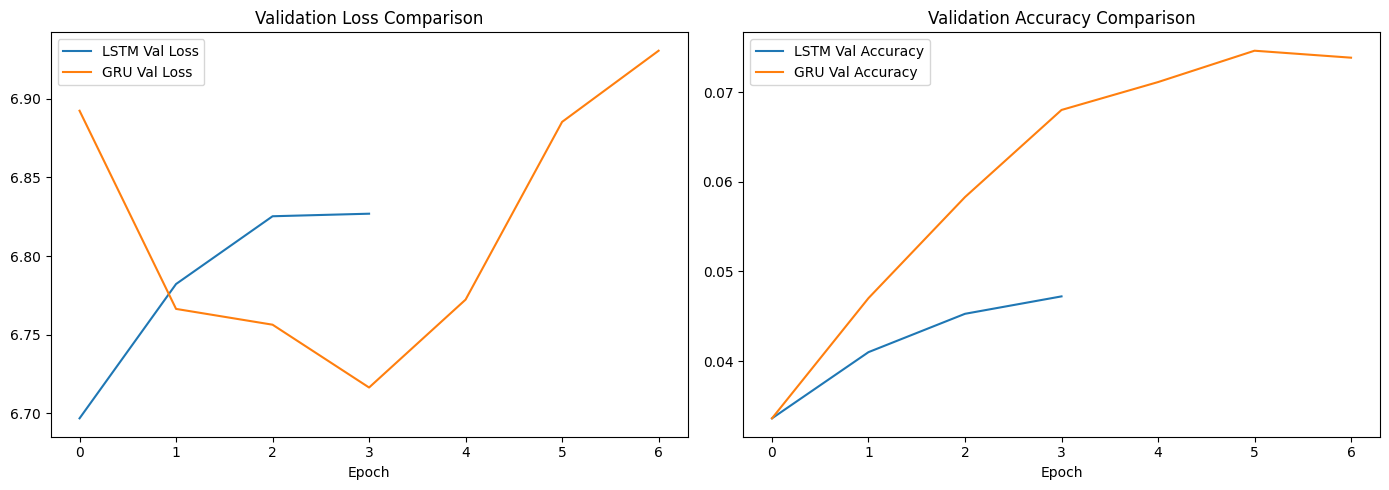

In [18]:
import matplotlib.pyplot as plt

# Final validation metrics
lstm_val_loss, lstm_val_acc = lstm_model.evaluate(x_test, y_test, verbose=0)
gru_val_loss, gru_val_acc = gru_model.evaluate(x_test, y_test, verbose=0)

print(f"LSTM -> Val Loss: {lstm_val_loss:.4f}, Val Accuracy: {lstm_val_acc:.4f}")
print(f"GRU  -> Val Loss: {gru_val_loss:.4f}, Val Accuracy: {gru_val_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lstm_history.history['val_loss'], label='LSTM Val Loss')
axes[0].plot(gru_history.history['val_loss'], label='GRU Val Loss')
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(lstm_history.history['val_accuracy'], label='LSTM Val Accuracy')
axes[1].plot(gru_history.history['val_accuracy'], label='GRU Val Accuracy')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_vs_gru_comparison.png')
plt.show()

In [19]:
# Function to predict the next word
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    if len(token_list) >= max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]  # Ensure the sequence length matches max_sequence_len-1
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [20]:
input_text="To be or not to be"
print(f"Input text:{input_text}")
max_sequence_len=lstm_model.input_shape[1]+1
next_word=predict_next_word(lstm_model,tokenizer,input_text,max_sequence_len)
print(f"Next Word Prediction:{next_word}")

Input text:To be or not to be
Next Word Prediction:the


In [21]:
## Save the model
lstm_model.save("next_word_lstm.keras")
## Save the tokenizer
import pickle
with open('tokenizer.pickle','wb') as handle:
    pickle.dump(tokenizer,handle,protocol=pickle.HIGHEST_PROTOCOL)

In [22]:
input_text="  Barn. Last night of all,When yond same"
print(f"Input text:{input_text}")
max_sequence_len=lstm_model.input_shape[1]+1
next_word=predict_next_word(lstm_model,tokenizer,input_text,max_sequence_len)
print(f"Next Word Prediction:{next_word}")

Input text:  Barn. Last night of all,When yond same
Next Word Prediction:the
